# Feature Selection

## Introduction

Feature Selection is the process of selecting the most relevant features from a dataset before training a Machine Learning model.

Instead of using every available feature, we keep only the important ones. This improves model performance, reduces overfitting, decreases training time, and makes the model easier to understand.

### Objectives

- Improve model accuracy
- Reduce overfitting
- Remove irrelevant features
- Reduce computational cost
- Improve model interpretability

# Filter Methods

Filter methods evaluate each feature using statistical techniques before training the model. They are fast, simple, and independent of any Machine Learning algorithm.

## Correlation Matrix

Correlation measures the relationship between numerical variables.

Correlation values range from **-1 to +1**.

- **+1** → Perfect Positive Correlation
- **-1** → Perfect Negative Correlation
- **0** → No Correlation

Highly correlated features usually contain similar information, so one of them can often be removed.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import (LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures) 

In [4]:
df = sns.load_dataset("titanic")

In [6]:
correlation_matrix = df.corr(numeric_only = True)

print(correlation_matrix.head())

          survived    pclass       age  ...      fare  adult_male     alone
survived  1.000000 -0.338481 -0.077221  ...  0.257307   -0.557080 -0.203367
pclass   -0.338481  1.000000 -0.369226  ... -0.549500    0.094035  0.135207
age      -0.077221 -0.369226  1.000000  ...  0.096067    0.280328  0.198270
sibsp    -0.035322  0.083081 -0.308247  ...  0.159651   -0.253586 -0.584471
parch     0.081629  0.018443 -0.189119  ...  0.216225   -0.349943 -0.583398

[5 rows x 8 columns]


### Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix, making it easier to identify highly correlated features.

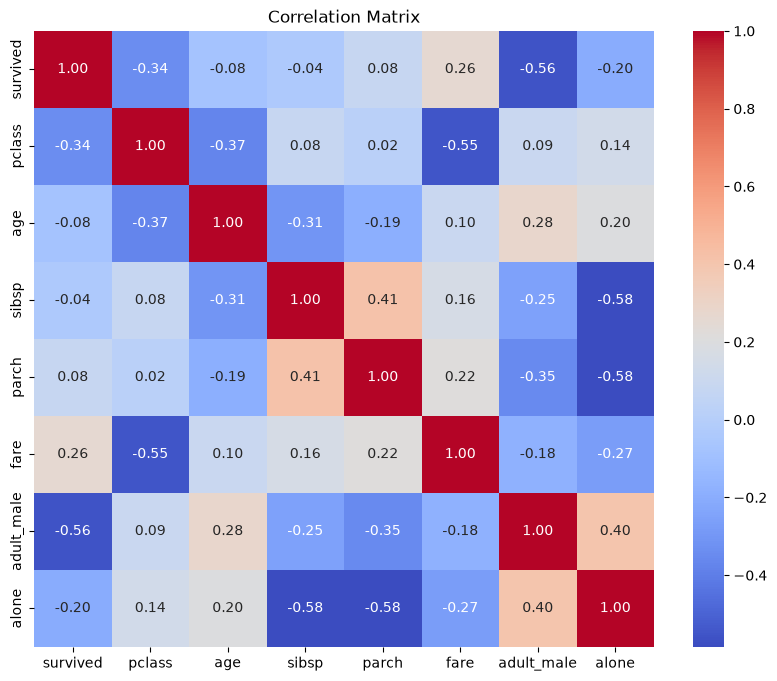

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm", fmt=".2f" )

plt.title("Correlation Matrix")
plt.show()

## Chi-Square Test

The Chi-Square test measures the relationship between categorical features and a categorical target variable.

A higher Chi-Square score indicates that the feature has a stronger relationship with the target variable.

In [10]:
from sklearn.preprocessing import LabelEncoder 
from sklearn.feature_selection import chi2

data = df.copy()

encoder = LabelEncoder()

data["sex"] = encoder.fit_transform(data["sex"])
data["embarked"] = encoder.fit_transform(data["embarked"])

x = data[["sex","embarked"]]
y = data["survived"]

chi_scores, p_values = chi2(x,y)

print("Chi-Square Scores:")
print(chi_scores)

print("\nP-values:")
print(p_values)

Chi-Square Scores:
[92.70244698  9.75545583]

P-values:
[6.07783826e-22 1.78791305e-03]


## ANOVA Test

ANOVA (Analysis of Variance) compares the mean values of two or more groups.

It is commonly used when:

- Input Feature → Numerical
- Target Variable → Categorical

Example:
Compare whether passenger age differs between survivors and non-survivors.

In [11]:
from scipy.stats import f_oneway 

survived = df[df["survived"] == 1]["age"].dropna()

not_survived = df[df["survived"] == 0]["age"].dropna()

f_stat, p_value = f_oneway(survived, not_survived)

print("F-Statistics: ", f_stat)
print("P_value:", p_value)

F-Statistics:  4.271194933815904
P_value: 0.039124654013482356


# Wrapper Methods

Wrapper methods evaluate different feature combinations by repeatedly training a Machine Learning model.

Although more computationally expensive, they often produce better feature subsets.

## Recursive Feature Elimination (RFE)

Recursive Feature Elimination (RFE) starts with all features and removes the least important feature at each iteration until the desired number of features remains.

In [13]:
from sklearn.feature_selection import RFE 
from sklearn.linear_model import LogisticRegression 

x = df.select_dtypes(include = ["number"]).drop(columns=["survived"])
y = df["survived"]

x = x.fillna(x.median())

model = LogisticRegression(max_iter=1000)

rfe = RFE(estimator=model, n_features_to_select=5)

rfe.fit(x,y)

print("Selected Features:")

print(x.columns[rfe.support_])


Selected Features:
Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')


## Forward Selection

Forward Selection begins with no features and adds one feature at a time based on model performance.

The process stops when adding more features no longer improves the model.

> **Note:** Scikit-learn does not provide a built-in implementation of Forward Selection. Libraries such as **mlxtend** are commonly used.

## Backward Selection

Backward Selection starts with all available features and removes the least useful feature at each iteration until the optimal subset is obtained.

# Embedded Methods

Embedded methods perform feature selection during model training. These methods are efficient because feature selection is integrated into the learning algorithm.

## Lasso Regression (L1 Regularization)

Lasso Regression applies L1 regularization and automatically removes less important features by shrinking their coefficients to zero.

In [14]:
from sklearn.linear_model import Lasso 

lasso = Lasso(alpha=0.01)

lasso.fit(x,y)

print("Lasso Coefficient:")
print(lasso.coef_)

Lasso Coefficient:
[-0.18404313 -0.00711672 -0.02889227  0.02028879  0.00102545]


## Ridge Regression (L2 Regularization)

Ridge Regression applies L2 regularization. Instead of removing features, it reduces the magnitude of feature coefficients.

In [15]:
from sklearn.linear_model import Ridge 

ridge = Ridge(alpha=0.01)

ridge.fit(x,y)

print("Ridge Coefficient:")
print(ridge.coef_)

Ridge Coefficient:
[-0.20784084 -0.00760964 -0.0430453   0.04606066  0.00078173]


## Random Forest Feature Importance

Random Forest automatically calculates feature importance based on how much each feature contributes to making accurate predictions.

In [16]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

model = RandomForestClassifier(random_state=42)

model.fit(x,y)

feature_importance = pd.DataFrame({"Feature" : x.columns, "Importance":model.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

print(feature_importance)

  Feature  Importance
4    fare    0.422973
1     age    0.378792
0  pclass    0.088434
2   sibsp    0.063053
3   parch    0.046748


### Feature Importance Visualization

The following bar chart shows the importance score of each feature calculated by the Random Forest model.

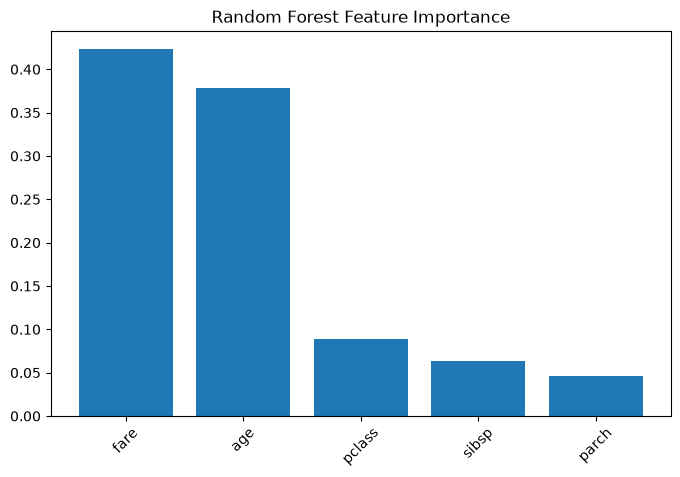

In [18]:
import matplotlib.pyplot as plt 

plt.figure(figsize = (8,5))

plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.xticks(rotation=45)

plt.title("Random Forest Feature Importance")

plt.show()

---
## 📝 Note

Selecting the right features improves model performance, reduces overfitting, and speeds up training. A smaller set of meaningful features often leads to more accurate and interpretable Machine Learning models.